# Market risk of a euro investor's currency portfolio: GJR-GARCH-t VaR and ES with regulatory backtesting

Official data: **ECB euro foreign exchange reference rates** (daily, since 4 January 1999).

The portfolio holds equal euro amounts in US dollars, pounds sterling, Japanese yen and Swiss francs, rebalanced daily.
We forecast the one-day 99% Value at Risk and 97.5% Expected Shortfall out of sample with

| model | description |
| --- | --- |
| HS | historical simulation on the last 500 days |
| GARCH-N | GARCH(1,1) with Gaussian innovations |
| GJR-t | GJR-GARCH(1,1) with standardised Student-t innovations (leverage effect + fat tails) |
| FHS | filtered historical simulation: GJR-t volatility x empirical standardised residuals |

Section 6 turns the risk measures into regulatory capital under FRTB and Basel 2.5; section 7 summarises the findings.

The GARCH models are re-estimated every 20 business days on a rolling window of 1,000 observations. This requires about 300
maximum-likelihood fits per model; the C++ engine runs them in parallel (Nelder-Mead, no Python callbacks).
The forecasts are then backtested with the Kupiec, Christoffersen and conditional coverage tests, the Basel traffic light and
the Acerbi-Szekely $Z_2$ test for ES.

**Requirements.** Build the extension with `python -m pip install -e scripts/quant_engine` (see the project README).
**Data.** `DATA_MODE = "official"` downloads `eurofxref-hist.zip` from the ECB and caches it in `data/raw/ecb/`;
`QUANT_ENGINE_DATA_MODE=synthetic` runs offline on simulated rates (not official data).

**Conventions.** Returns are daily log-returns in percent of the portfolio value in euro; VaR and ES are positive losses in percent.
The ECB publishes rates as units of foreign currency per euro, so the euro value of one unit of currency $i$ is $1/X_{i,t}$.

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "quant_engine").is_dir())
try:
    import quant_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "quant_engine"))
    import quant_engine
from quant_engine import data, garch, risk, synthetic

core = quant_engine.require_cpp()

DATA_MODE = os.environ.get("QUANT_ENGINE_DATA_MODE", "official")  # "official" (ECB) or "synthetic" (offline)
START, END = "1999-01-04", "2025-12-31"   # fixed sample for reproducibility
CURRENCIES = ("USD", "GBP", "JPY", "CHF")
WINDOW, REFIT_EVERY = 1000, 20            # estimation window and refit frequency (business days)
VAR_ALPHA, ES_ALPHA = 0.01, 0.025         # 99% VaR (Basel backtesting) and 97.5% ES (FRTB)
OUTPUT_DIR = ROOT / "outputs" / "fx_var_backtesting"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
from quant_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"quant_engine {quant_engine.__version__} | threads available: {os.cpu_count()} | data mode: {DATA_MODE}")

quant_engine 0.1.0 | threads available: 4 | data mode: official


## 1. Data and portfolio returns

Daily simple return of currency $i$ in euro: $R_{i,t} = X_{i,t-1}/X_{i,t} - 1$. Portfolio: $R_{p,t} = \frac{1}{4}\sum_i R_{i,t}$,
and we model $r_t = 100\,\ln(1 + R_{p,t})$.

Source: European Central Bank, euro foreign exchange reference rates (https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip)
6,912 daily returns from 1999-01-05 to 2025-12-31


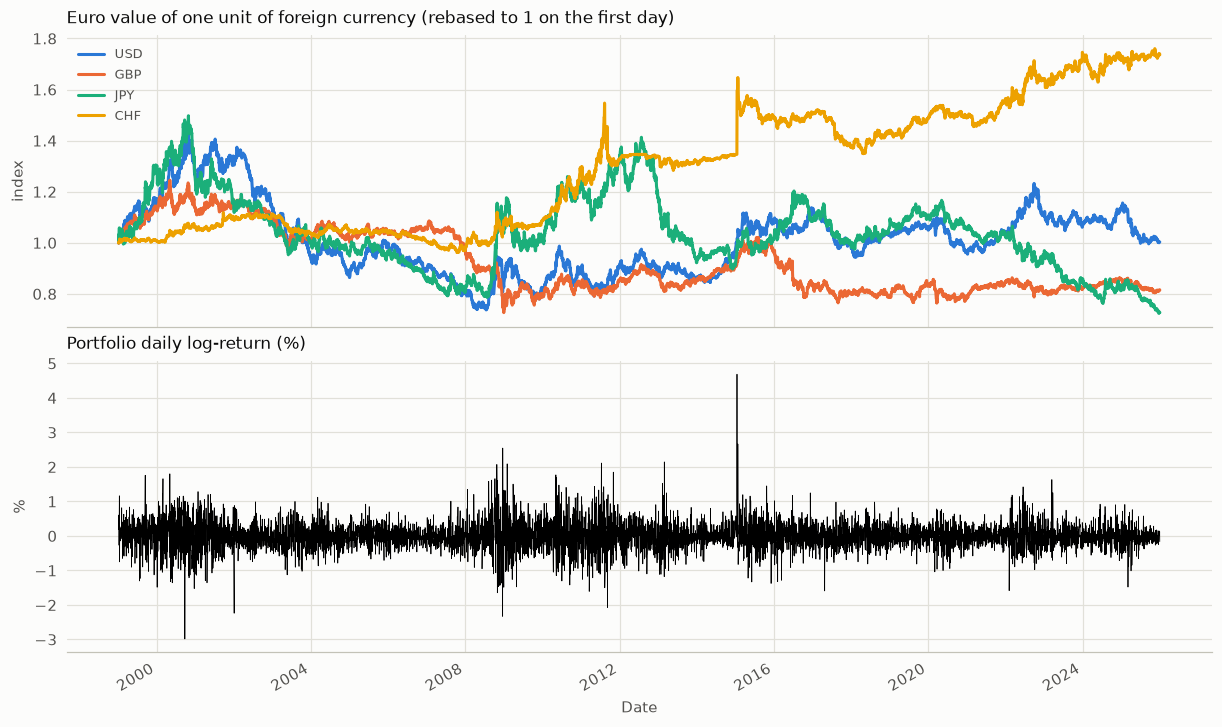

In [2]:
if DATA_MODE == "official":
    rates = data.load_ecb_fx_rates(CURRENCIES, start=START, end=END)
else:
    rates = synthetic.fx_rates(START, END)
print("Source:", rates.attrs.get("source"))
rates = rates.dropna()
simple = rates.shift(1) / rates - 1.0
port = 100.0 * np.log1p(simple.mean(axis=1)).dropna()
port.name = "portfolio"
print(f"{len(port):,} daily returns from {port.index[0]:%Y-%m-%d} to {port.index[-1]:%Y-%m-%d}")

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
(1.0 / rates / (1.0 / rates.iloc[0])).plot(ax=axes[0])
axes[0].set(title="Euro value of one unit of foreign currency (rebased to 1 on the first day)", ylabel="index")
port.plot(ax=axes[1], lw=0.5, color="k")
axes[1].set(title="Portfolio daily log-return (%)", ylabel="%")
fig.savefig(OUTPUT_DIR / "rates_and_returns.png", dpi=150)

In [3]:
def ljung_box(x, lags=20):
    """Ljung-Box Q statistic and chi-square p-value."""
    x = np.asarray(x) - np.mean(x)
    acf = np.array([np.sum(x[k:] * x[:-k]) for k in range(1, lags + 1)]) / np.sum(x * x)
    n = x.size
    q = n * (n + 2) * np.sum(acf**2 / (n - np.arange(1, lags + 1)))
    return q, stats.chi2.sf(q, lags)

all_returns = pd.concat([100 * np.log1p(simple).dropna(), port], axis=1)
rows = {}
for name, x in all_returns.items():
    jb = stats.jarque_bera(x)
    q_r, p_r = ljung_box(x)
    q_sq, p_sq = ljung_box(x**2)
    rows[name] = {"ann. volatility (%)": x.std() * np.sqrt(252), "skewness": stats.skew(x),
                  "excess kurtosis": stats.kurtosis(x), "min (%)": x.min(), "max (%)": x.max(),
                  "Jarque-Bera p": jb.pvalue, "Ljung-Box(20) r p": p_r, "Ljung-Box(20) r^2 p": p_sq}
display(pd.DataFrame(rows).T)
print("Fat tails (excess kurtosis > 0) and strong autocorrelation of squared returns motivate GARCH with Student-t innovations.")

,ann. volatility (%),skewness,excess kurtosis,min (%),max (%),Jarque-Bera p,Ljung-Box(20) r p,Ljung-Box(20) r^2 p
USD,9.2982,-0.0431,3.2503,-4.2041,4.7354,0.0000,0.0052,0.0000
GBP,7.6710,-0.4575,5.6292,-5.2826,2.9686,0.0000,0.0001,0.0000
JPY,11.2926,0.3178,4.8807,-5.3963,6.1232,0.0000,0.0844,0.0000
CHF,6.3617,7.2259,356.7489,-7.9967,15.5539,0.0000,0.0000,0.6717
portfolio,6.1728,0.4062,6.5368,-2.9858,4.6859,0.0000,0.0122,0.0000


Fat tails (excess kurtosis > 0) and strong autocorrelation of squared returns motivate GARCH with Student-t innovations.


## 2. Full-sample estimation

$$ r_t = \mu + \varepsilon_t,\qquad \varepsilon_t = \sigma_t z_t,\qquad
   \sigma_t^2 = \omega + (\alpha + \gamma\,\mathbb{1}\{\varepsilon_{t-1}<0\})\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2 $$

with $z_t$ standard normal or unit-variance Student-t. Standard errors come from the inverse numerical Hessian.
The C++ estimate is cross-checked against an independent SciPy (SLSQP) fit of a pure Python likelihood.

In [4]:
fits = {}
for model in ("garch", "gjr"):
    for dist in ("normal", "t"):
        t0 = time.perf_counter()
        fits[f"{model.upper()}-{'N' if dist == 'normal' else 't'}"] = garch.fit(port, model, dist)
        print(f"{model:>5}-{dist:<6}: {time.perf_counter() - t0:.2f} s")
comparison = pd.DataFrame({name: {"log-likelihood": f.loglik, "AIC": f.aic, "BIC": f.bic,
                                  "persistence": f.persistence, "half-life (days)": f.half_life,
                                  **{k: f.params[k] for k in ("alpha", "gamma", "beta", "nu")}}
                           for name, f in fits.items()}).T
display(comparison)
display(fits["GJR-t"].summary())

t0 = time.perf_counter()
reference = garch.fit_reference(port, "gjr", "t")
t_ref = time.perf_counter() - t0
print(f"SciPy reference fit: {t_ref:.1f} s, log-likelihood {reference.loglik:.6f} "
      f"(C++: {fits['GJR-t'].loglik:.6f}, difference {fits['GJR-t'].loglik - reference.loglik:+.2e})")

garch-normal: 0.09 s


garch-t     : 0.14 s


  gjr-normal: 0.09 s


  gjr-t     : 0.20 s


,log-likelihood,AIC,BIC,persistence,half-life (days),alpha,gamma,beta,nu
GARCH-N,"-2,536.8033","5,081.6066","5,108.9707",0.9953,148.2136,0.0511,0.0000,0.9443,0.0000
GARCH-t,"-2,289.6431","4,589.2861","4,623.4912",0.9970,233.9164,0.0399,0.0000,0.9572,7.2449
GJR-N,"-2,520.3219","5,050.6439","5,084.8490",0.9953,146.8926,0.0643,-0.0344,0.9482,0.0000
GJR-t,"-2,289.5059","4,591.0117","4,632.0578",0.9969,226.4044,0.0413,-0.0036,0.9575,7.2573


,estimate,std_error
mu,-0.0054,0.0035
omega,0.0005,0.0002
alpha,0.0413,0.0055
gamma,-0.0036,0.0068
beta,0.9575,0.0049
nu,7.2573,0.5705


SciPy reference fit: 2.5 s, log-likelihood -2289.505862 (C++: -2289.505862, difference +2.21e-08)


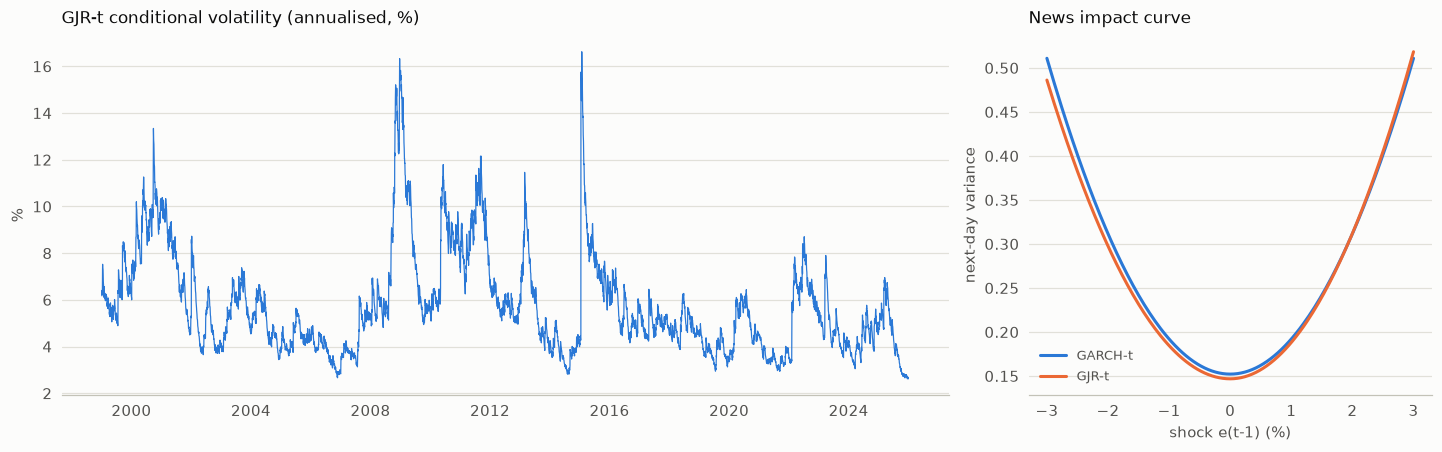

In [5]:
best = fits["GJR-t"]
sigma = np.sqrt(garch.conditional_variance(port, best.params, "gjr", "t")[:-1])
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2.2, 1]})
axes[0].plot(port.index, sigma * np.sqrt(252), lw=0.8)
axes[0].set(title="GJR-t conditional volatility (annualised, %)", ylabel="%")
shocks = np.linspace(-3, 3, 201)
for name in ("GARCH-t", "GJR-t"):
    axes[1].plot(shocks, garch.news_impact_curve(fits[name], shocks), label=name)
axes[1].set(title="News impact curve", xlabel="shock e(t-1) (%)", ylabel="next-day variance")
axes[1].legend()
fig.savefig(OUTPUT_DIR / "conditional_volatility.png", dpi=150)

## 3. Rolling out-of-sample forecasts

The forecast for day $t$ uses only returns up to $t-1$. HS uses the last 500 returns; the GARCH models use the last 1,000 returns
with parameters re-estimated every 20 days. Parametric VaR/ES follow from the Gaussian or Student-t quantiles;
FHS applies the empirical quantile of the standardised residuals $\hat z$ of the window.

GJR-t: 296 fits + 5,912 forecasts in 2.4 s; GARCH-N in 0.8 s (all fits converged: True)
Estimated time with the SciPy reference estimator: 1.8 minutes per model (from the full-sample timing, scaled to the window length)


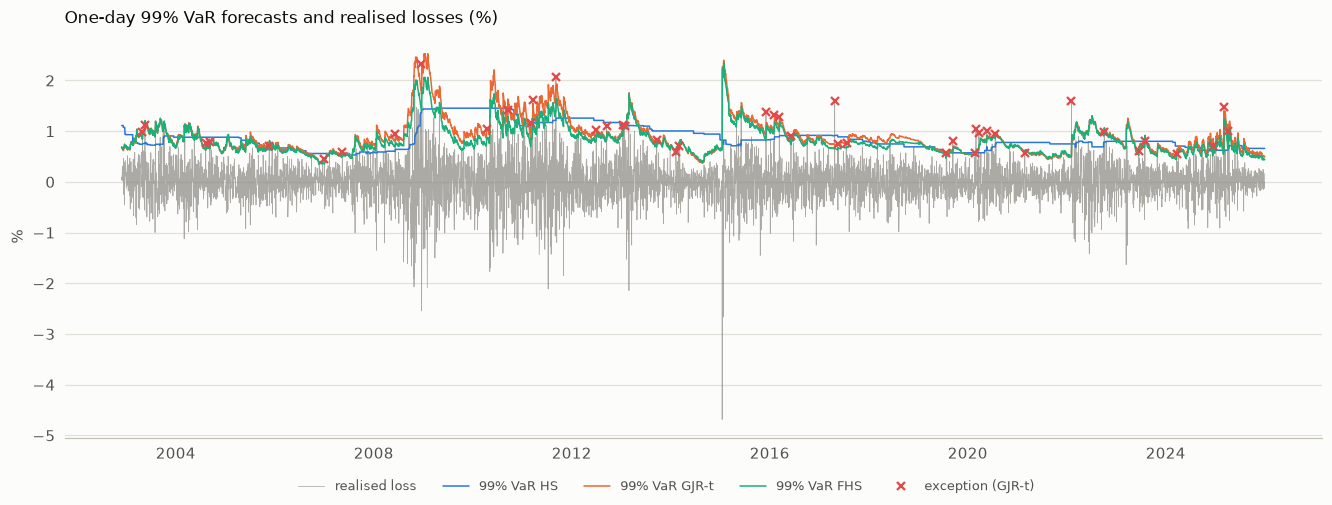

In [6]:
t0 = time.perf_counter()
gjr = garch.rolling_forecast(port, WINDOW, REFIT_EVERY, "gjr", "t", alphas=(VAR_ALPHA, ES_ALPHA))
t_gjr = time.perf_counter() - t0
t0 = time.perf_counter()
gn = garch.rolling_forecast(port, WINDOW, REFIT_EVERY, "garch", "normal", alphas=(VAR_ALPHA, ES_ALPHA))
t_gn = time.perf_counter() - t0
n_fits = len(gjr.attrs["params"])
print(f"GJR-t: {n_fits} fits + {len(gjr):,} forecasts in {t_gjr:.1f} s; GARCH-N in {t_gn:.1f} s "
      f"(all fits converged: {gjr.attrs['converged'].all() and gn.attrs['converged'].all()})")
print(f"Estimated time with the SciPy reference estimator: {n_fits * t_ref * WINDOW / len(port) / 60:.1f} minutes per model "
      "(from the full-sample timing, scaled to the window length)")

idx = gjr.index
var, es, var_es_level = {}, {}, {}
hs99 = risk.historical_var_es(port, 500, VAR_ALPHA).reindex(idx)
hs975 = risk.historical_var_es(port, 500, ES_ALPHA).reindex(idx)
var["HS"], es["HS"], var_es_level["HS"] = hs99["var"], hs975["es"], hs975["var"]
v, _ = risk.normal_var_es(gn["mu"], gn["sigma"], VAR_ALPHA)
v2, e2 = risk.normal_var_es(gn["mu"], gn["sigma"], ES_ALPHA)
var["GARCH-N"], es["GARCH-N"], var_es_level["GARCH-N"] = v, e2, v2
v, _ = risk.student_t_var_es(gjr["mu"], gjr["sigma"], gjr["nu"], VAR_ALPHA)
v2, e2 = risk.student_t_var_es(gjr["mu"], gjr["sigma"], gjr["nu"], ES_ALPHA)
var["GJR-t"], es["GJR-t"], var_es_level["GJR-t"] = v, e2, v2
var["FHS"], es["FHS"] = gjr[f"fhs_var_{VAR_ALPHA:g}"], gjr[f"fhs_es_{ES_ALPHA:g}"]
var_es_level["FHS"] = gjr[f"fhs_var_{ES_ALPHA:g}"]
var = pd.DataFrame(var, index=idx)
es = pd.DataFrame(es, index=idx)
var_es_level = pd.DataFrame(var_es_level, index=idx)
realised = port.reindex(idx)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(idx, -realised, color=MUTED, lw=0.5, alpha=0.7, label="realised loss")
for name in ("HS", "GJR-t", "FHS"):
    ax.plot(idx, var[name], lw=1.0, label=f"99% VaR {name}")
hits = -realised > var["GJR-t"]
ax.plot(idx[hits], -realised[hits], "x", color=NEGATIVE, ms=5, mew=1.5, label="exception (GJR-t)")
ax.set(title="One-day 99% VaR forecasts and realised losses (%)", ylabel="%")
fig.legend(loc="outside lower center", ncol=5)
fig.savefig(OUTPUT_DIR / "var_forecasts.png", dpi=150)

## 4. Backtesting

- **Kupiec (1995)**: is the exception rate equal to 1%?
- **Christoffersen (1998)**: are exceptions independent (no clustering)? Conditional coverage combines both.
- **Acerbi-Szekely (2014) $Z_2$** for the 97.5% ES: approximately 0 under a correct model; the authors report
  critical values of about 0.70 (5%) and 1.80 (0.01%).

Low p-values reject the model.

In [7]:
table = risk.backtest_table(realised, {k: var[k] for k in var}, VAR_ALPHA)
z2 = {name: risk.acerbi_szekely_z2(-realised, var_es_level[name], es[name], ES_ALPHA) for name in var}
table["ES 97.5% Z2"] = pd.Series(z2)
table["mean VaR (%)"] = var.mean()
display(table)
table.to_csv(OUTPUT_DIR / "backtest_summary.csv")

,observations,exceptions,expected,exception rate,Kupiec p,independence p,cond. coverage p,ES 97.5% Z2,mean VaR (%)
HS,"5,912.0000",80.0000,59.1200,0.0135,0.0096,0.1233,0.0107,0.1564,0.8695
GARCH-N,"5,912.0000",53.0000,59.1200,0.0090,0.4155,0.3274,0.4444,-0.1049,0.8416
GJR-t,"5,912.0000",44.0000,59.1200,0.0074,0.0384,0.4166,0.0843,-0.1897,0.8965
FHS,"5,912.0000",66.0000,59.1200,0.0112,0.3773,0.2221,0.3214,0.0178,0.8202


In [8]:
# Basel traffic light by calendar year (about 250 business days each).
exceptions = (-realised.to_numpy()[:, None] > var.to_numpy()).astype(int)
yearly = pd.DataFrame(exceptions, index=idx, columns=var.columns).groupby(idx.year).sum()
zones = yearly.apply(lambda col: col.map(risk.basel_traffic_light))
summary = yearly.astype(str) + " (" + zones + ")"
summary["observations"] = pd.Series(idx.year).value_counts().sort_index().to_numpy()
display(summary)
print("Zones for 250 observations at 99%: green 0-4, yellow 5-9, red 10 or more exceptions.")
print("Share of red years:", (zones == "red").mean().round(3).to_dict())

,HS,GARCH-N,GJR-t,FHS,observations
Date,,,,,
2002,0 (green),0 (green),0 (green),0 (green),22
2003,6 (yellow),3 (green),2 (green),2 (green),255
2004,0 (green),3 (green),2 (green),2 (green),259
2005,1 (green),1 (green),1 (green),1 (green),257
2006,0 (green),0 (green),0 (green),1 (green),255
2007,6 (yellow),2 (green),2 (green),2 (green),255
2008,18 (red),2 (green),2 (green),3 (green),256
2009,1 (green),0 (green),0 (green),2 (green),256
2010,0 (green),2 (green),2 (green),4 (green),258


Zones for 250 observations at 99%: green 0-4, yellow 5-9, red 10 or more exceptions.
Share of red years: {'HS': 0.042, 'GARCH-N': 0.0, 'GJR-t': 0.0, 'FHS': 0.0}


## 5. Stress episodes

The largest portfolio losses and the VaR forecasts made the day before. Episodes include the global financial crisis,
the Brexit referendum (24 June 2016) and the pandemic shock of March 2020. Note that the removal of the Swiss franc floor on
15 January 2015 was a large **gain** for this portfolio, which is long CHF.

In [9]:
worst = realised.nsmallest(12).index.sort_values()
stress = pd.concat([(-realised[worst]).rename("loss (%)"), var.loc[worst].add_prefix("VaR ")], axis=1)
display(stress)
print(f"Largest gain in the sample: {port.max():.2f}% on {port.idxmax():%Y-%m-%d}")

,loss (%),VaR HS,VaR GARCH-N,VaR GJR-t,VaR FHS
Date,,,,,
2008-10-29,1.6463,0.7822,1.9955,2.3127,1.8703
2008-10-30,1.4535,0.8928,2.0961,2.2829,1.8461
2008-11-10,1.4706,0.9519,2.2217,2.3957,1.9545
2008-12-18,2.3299,1.3680,1.9558,1.7313,1.4034
2008-12-29,1.4866,1.4262,2.3934,2.1785,1.7692
2009-04-29,1.4750,1.4374,1.5566,1.6788,1.3690
2011-03-18,1.6067,1.1503,1.1671,1.2503,1.0063
2011-08-12,1.5001,1.1712,1.5499,1.7790,1.4149
2011-09-06,2.0733,1.2123,1.5295,1.6835,1.3926


Largest gain in the sample: 4.69% on 2015-01-15


## 6. Regulatory capital: FRTB internal models approach versus Basel 2.5

How much market-risk capital would a bank hold for this currency book? Under the **Fundamental Review of the Trading Book**
(Basel Committee, MAR33) the internal-models capital is based on the **97.5% Expected Shortfall over 10 days**, computed on overlapping
10-day returns and **calibrated to a stressed 12-month period**. The four currency pairs are "specified currency pairs" with a 10-day
liquidity horizon, and with a single risk class the ratio between current full and reduced ES is one, so the charge reduces to the
stressed ES. The capital requirement is $\max(\text{IMCC}_{t-1},\ m_c \cdot \overline{\text{IMCC}}_{60})$ with $m_c = 1.5$ in the green
backtesting zone and up to 2.0 in the red zone. For comparison, **Basel 2.5** required
$\max(\text{VaR}_{t-1}, m\,\overline{\text{VaR}}_{60}) + \max(\text{sVaR}_{t-1}, m_s\,\overline{\text{sVaR}}_{60})$ with 99% 10-day VaR
(square-root-of-time scaling of the 1-day VaR) and $m = 3$ plus the traffic-light add-on. Both measures use historical simulation here;
the backtesting zone uses the exceptions of the filtered-historical-simulation 99% VaR over the last 250 days. Default resampling
risk, non-modellable risk factors and the standardised-approach floor are outside the scope.

,2025-12-31
"10-day 97.5% ES, last 12 months (%)",2.6128
stressed 10-day 97.5% ES (%),5.9700
stressed window,2008-04-01 to 2009-03-20
"FHS 99% VaR exceptions, last 250 days",4
FRTB multiplier,1.5000
FRTB capital (% of book),8.9551
Basel 2.5 10-day VaR + stressed VaR (%),7.4340
Basel 2.5 multiplier,3.0000
Basel 2.5 capital (% of book),22.3020
FRTB capital on EUR 100 million,"EUR 8,955,055"


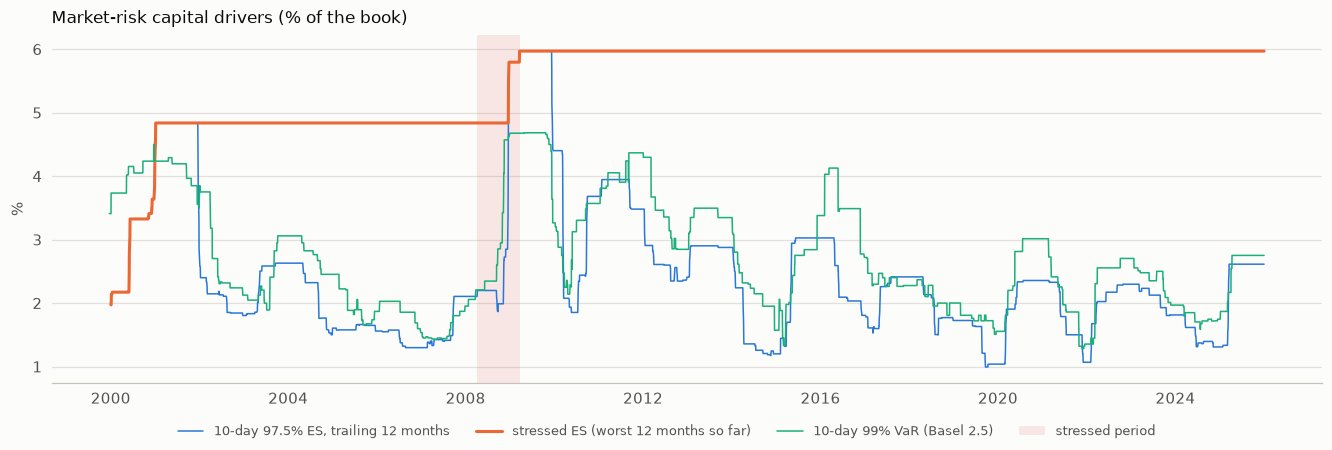

In [10]:
PORTFOLIO_EUR = 100_000_000   # illustrative size of the currency book
es10 = risk.rolling_historical_es(port, horizon=10, window=250, alpha=0.025)
imcc = es10["es"].cummax()     # stressed ES: worst 12-month window observed up to each date
stress = risk.stressed_period(port, horizon=10, window=250, alpha=0.025)

var1 = risk.rolling_historical_es(port, horizon=1, window=250, alpha=0.01)["var"]
var10 = np.sqrt(10) * var1
svar10 = var10.cummax()

fhs_hits = (-realised > var["FHS"]).astype(int)
exceptions = int(fhs_hits.iloc[-250:].sum())
m_frtb, m_b25 = risk.frtb_multiplier(exceptions), risk.basel25_multiplier(exceptions)
frtb_cap = risk.capital_charge(imcc, m_frtb)
b25_cap = risk.capital_charge(var10, m_b25) + risk.capital_charge(svar10, m_b25)

summary = pd.Series({
    "10-day 97.5% ES, last 12 months (%)": es10["es"].iloc[-1],
    "stressed 10-day 97.5% ES (%)": imcc.iloc[-1],
    "stressed window": f"{stress['start']:%Y-%m-%d} to {stress['end']:%Y-%m-%d}",
    "FHS 99% VaR exceptions, last 250 days": exceptions,
    "FRTB multiplier": m_frtb,
    "FRTB capital (% of book)": frtb_cap,
    "Basel 2.5 10-day VaR + stressed VaR (%)": var10.iloc[-1] + svar10.iloc[-1],
    "Basel 2.5 multiplier": m_b25,
    "Basel 2.5 capital (% of book)": b25_cap,
    f"FRTB capital on EUR {PORTFOLIO_EUR / 1e6:.0f} million": f"EUR {frtb_cap / 100 * PORTFOLIO_EUR:,.0f}",
    f"Basel 2.5 capital on EUR {PORTFOLIO_EUR / 1e6:.0f} million": f"EUR {b25_cap / 100 * PORTFOLIO_EUR:,.0f}",
}, name=f"{port.index[-1]:%Y-%m-%d}")
display(summary.to_frame())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(es10.index, es10["es"], lw=1.0, color=SERIES[0], label="10-day 97.5% ES, trailing 12 months")
ax.plot(imcc.index, imcc, lw=2.0, color=SERIES[1], label="stressed ES (worst 12 months so far)")
ax.plot(var10.index, var10, lw=1.0, color=SERIES[2], label="10-day 99% VaR (Basel 2.5)")
ax.axvspan(stress["start"], stress["end"], color=NEGATIVE, alpha=0.12, lw=0, label="stressed period")
ax.set(title="Market-risk capital drivers (% of the book)", ylabel="%")
fig.legend(loc="outside lower center", ncol=4)
fig.savefig(OUTPUT_DIR / "frtb_capital.png", dpi=150)

## 7. Conclusions and caveats

Results obtained with the official ECB data for the sample 4 January 1999 - 31 December 2025
(5,912 out-of-sample days from December 2002; in synthetic mode the numbers differ):

- **Stylised facts.** The portfolio has an annualised volatility of about 6%, excess kurtosis above 6 and very strong
  autocorrelation in squared returns.
- **Estimation.** Student-t innovations ($\nu \approx 7$) raise the log-likelihood by about 250 points over the Gaussian model.
  Volatility is very persistent (half-life of roughly 230 days). With Student-t innovations the leverage coefficient is
  essentially zero ($\gamma \approx -0.004$, standard error 0.007): exchange-rate volatility is symmetric for a euro investor,
  unlike equity volatility. The negative $\gamma$ of the Gaussian GJR model most likely compensates for the fat tails.
- **Historical simulation** fails: 80 exceptions against 59 expected (1.35%, Kupiec p about 0.01), 18 exceptions and a
  red traffic light in 2008, and a positive $Z_2$ (ES underestimated).
- **Gaussian GARCH** passes the 99% VaR tests (0.90%), while its negative $Z_2$ shows that it overstates the 97.5% ES.
- **Parametric GJR-t** is too conservative at 99% (0.74%, Kupiec p about 0.04): a Student-t fitted to the whole distribution
  puts too much mass in the extreme tail of this portfolio.
- **Filtered historical simulation** gives the best calibration: 1.12% exceptions, independent exceptions and $Z_2$ close to 0.
  Combining GARCH volatility with the empirical distribution of standardised residuals is the most reliable choice here.
- 2020 (pandemic shock) is a yellow year for every model.
- **Capital.** The FRTB stressed period is April 2008 - March 2009. With a stressed 10-day 97.5% ES of about 6% and a green-zone
  multiplier of 1.5, the FRTB internal-models charge is about 9% of the book, against about 22% under Basel 2.5 (VaR plus stressed
  VaR, both multiplied by 3). For a liquid, linear currency book with a 10-day liquidity horizon FRTB is therefore less punitive;
  the higher FRTB charges seen in practice come from longer liquidity horizons, non-modellable risk factors, the default risk charge,
  desk-level P&L attribution tests and the standardised-approach floor, which are outside the scope of this exercise.

Caveats: the portfolio ignores interest earned on the foreign deposits (carry); ECB reference rates are fixings taken around
14:10 CET, not tradable closing prices; yearly traffic-light counts use calendar years rather than exact 250-day windows.

### References

- Acerbi, C. and Szekely, B. (2014). Backtesting expected shortfall. *Risk*, December.
- Basel Committee on Banking Supervision (1996). Supervisory framework for the use of "backtesting" in conjunction with the internal models approach to market risk capital requirements.
- Basel Committee on Banking Supervision (2019). Minimum capital requirements for market risk (FRTB), MAR33 and MAR99.
- Barone-Adesi, G., Giannopoulos, K. and Vosper, L. (1999). VaR without correlations for portfolios of derivative securities. *Journal of Futures Markets*, 19(5), 583-602.
- Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307-327.
- Christoffersen, P. F. (1998). Evaluating interval forecasts. *International Economic Review*, 39(4), 841-862.
- Glosten, L. R., Jagannathan, R. and Runkle, D. E. (1993). On the relation between the expected value and the volatility of the nominal excess return on stocks. *Journal of Finance*, 48(5), 1779-1801.
- Kupiec, P. H. (1995). Techniques for verifying the accuracy of risk measurement models. *Journal of Derivatives*, 3(2), 73-84.
- McNeil, A. J., Frey, R. and Embrechts, P. (2015). *Quantitative Risk Management*, revised edition. Princeton University Press.
- European Central Bank. Euro foreign exchange reference rates: https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/index.en.html